# Hybrid LSTM + K-Means — Final Production Notebook

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              silhouette_score, r2_score)
import joblib, warnings, json
from pathlib import Path

# Use tf.keras aliases so the notebook works cleanly with Keras 3.
Model = tf.keras.Model
LSTM = tf.keras.layers.LSTM
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout
Input = tf.keras.layers.Input
Concatenate = tf.keras.layers.Concatenate
EarlyStopping = tf.keras.callbacks.EarlyStopping
ReduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau
ModelCheckpoint = tf.keras.callbacks.ModelCheckpoint

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)
print('Pandas:', pd.__version__)

TensorFlow: 2.15.0
Pandas: 2.3.3


## 1. Load Data

In [4]:
df = pd.read_csv('../data/cleaned_data_enriched.csv')
print('Raw shape:', df.shape)
print('Households:', df['household_id'].nunique())
print('Columns:', df.columns.tolist())
print()
print(df[['household_id','month','monthly_kwh','target']].head(5).to_string())

Raw shape: (15105, 27)
Households: 1438
Columns: ['household_id', 'month', 'monthly_kwh', 'prev1', 'prev2', 'prev3', 'target', 'peak_ratio', 'family_size', 'has_refrigerator', 'has_ac', 'has_geyser', 'has_electric_cooking', 'has_washing_machine', 'has_water_pump', 'work_from_home', 'no_members_wfh', 'avg_hours_wfh', 'temp', 'humidity', 'rain', 'inverter_ac', 'non_inverter_ac', 'has_solar', 'water_heater_solar', 'led_ratio', 'ac_hours_per_day']

  household_id  month  monthly_kwh   target
0       ID0013      3      294.139  175.646
1       ID0013      4      175.646  149.361
2       ID0013      5      168.025  149.978
3       ID0013      6      168.842  164.528
4       ID0013      7      156.287  159.222


In [5]:
print(df.columns)

Index(['household_id', 'month', 'monthly_kwh', 'prev1', 'prev2', 'prev3',
       'target', 'peak_ratio', 'family_size', 'has_refrigerator', 'has_ac',
       'has_geyser', 'has_electric_cooking', 'has_washing_machine',
       'has_water_pump', 'work_from_home', 'no_members_wfh', 'avg_hours_wfh',
       'temp', 'humidity', 'rain', 'inverter_ac', 'non_inverter_ac',
       'has_solar', 'water_heater_solar', 'led_ratio', 'ac_hours_per_day'],
      dtype='object')


## 2. Data Cleaning

**Bug 1 fix:** The previous notebook clipped at > 400 kWh. This removed 1,784
perfectly valid rows — a household using 250–400 kWh/month is normal.

The only rows that need removing are:
- 14 households with data entry errors (values in the millions)
- 1 commercial-scale household (ID3624, median > 1,000 kWh)
- Single-row spikes where `target > 4× that household's mean`
- Near-zero targets (missing next-month records)

In [6]:
# Stage A: Remove households with IMPOSSIBLE values (>400 kWh = data error)
corrupt_mask = (
    (df['monthly_kwh'] > 400) | (df['target'] > 400)
)
corrupt_hh_A = set(df[corrupt_mask]['household_id'].unique())
print(f'Stage A — corrupt households (>400 kWh): {len(corrupt_hh_A)}')
print(f'  IDs: {sorted(corrupt_hh_A)}')

# Stage B: Commercial-scale (median monthly > 1000 kWh)
hh_median = df.groupby('household_id')['monthly_kwh'].median()
corrupt_hh_B = set(hh_median[hh_median > 1000].index)
print(f'Stage B — commercial households (median>1000 kWh): {len(corrupt_hh_B)}')
if corrupt_hh_B:
    print(f'  IDs: {sorted(corrupt_hh_B)}')

all_corrupt = corrupt_hh_A | corrupt_hh_B
df1 = df[~df['household_id'].isin(all_corrupt)].copy()

# Stage C: Single-row spikes (target > 4× household mean)
hh_mean_t = df1.groupby('household_id')['target'].mean().rename('hh_mean')
df1 = df1.merge(hh_mean_t, on='household_id')
spike_mask = df1['target'] > df1['hh_mean'] * 4
print(f'Stage C — single-row spikes: {spike_mask.sum()} rows removed')
df1 = df1[~spike_mask].drop(columns=['hh_mean'])

# Stage D: Near-zero targets
before = len(df1)
df1 = df1[(df1['target'] >= 5) & (df1['monthly_kwh'] >= 5)].copy()
print(f'Stage D — near-zero targets: {before - len(df1)} rows removed')

df1 = df1.reset_index(drop=True)
print()
print(f'Final clean shape: {df1.shape}')
print(f'Final households:  {df1["household_id"].nunique()}')
print()
print('target distribution:')
print(df1['target'].describe().round(1).to_string())

Stage A — corrupt households (>400 kWh): 128
  IDs: ['ID0018', 'ID0043', 'ID0066', 'ID0127', 'ID0154', 'ID0177', 'ID0189', 'ID0198', 'ID0210', 'ID0246', 'ID0250', 'ID0264', 'ID0276', 'ID0296', 'ID0381', 'ID0417', 'ID0457', 'ID0544', 'ID0545', 'ID0551', 'ID0555', 'ID0558', 'ID0596', 'ID0600', 'ID0671', 'ID0733', 'ID0741', 'ID0772', 'ID0781', 'ID0796', 'ID0841', 'ID0844', 'ID0954', 'ID0987', 'ID1009', 'ID1028', 'ID1051', 'ID1097', 'ID1127', 'ID1132', 'ID1165', 'ID1184', 'ID1251', 'ID1284', 'ID1290', 'ID1377', 'ID1400', 'ID1496', 'ID1510', 'ID1581', 'ID1625', 'ID1653', 'ID1659', 'ID1672', 'ID1680', 'ID1683', 'ID1721', 'ID1743', 'ID1751', 'ID1762', 'ID1771', 'ID1777', 'ID1781', 'ID1978', 'ID1985', 'ID1992', 'ID2027', 'ID2042', 'ID2167', 'ID2194', 'ID2220', 'ID2221', 'ID2223', 'ID2278', 'ID2312', 'ID2323', 'ID2391', 'ID2420', 'ID2422', 'ID2440', 'ID2486', 'ID2584', 'ID2588', 'ID2616', 'ID2632', 'ID2660', 'ID2747', 'ID2770', 'ID2774', 'ID2781', 'ID2923', 'ID3029', 'ID3058', 'ID3063', 'ID3066

## 3. Feature Engineering

This version keeps monthly sequence features for LSTM and uses a compact behavior vector.

Behavior features are now:
- `ac_usage = has_ac * ac_hours_per_day`
- `wfh_impact = avg_hours_wfh * family_size`
- `energy_intensity = monthly_kwh / family_size`
- `ac_fraction = ac_usage / monthly_kwh`

Weather columns may exist in the dataset, but they are not used in model training.

In [7]:
df1 = df1.sort_values(['household_id', 'month']).reset_index(drop=True)

# Lag features: past monthly kWh values for the same household.
# These are safe because they only use earlier months within each household.
df1['lag_1'] = df1.groupby('household_id')['monthly_kwh'].shift(1)
df1['lag_2'] = df1.groupby('household_id')['monthly_kwh'].shift(2)
df1['lag_3'] = df1.groupby('household_id')['monthly_kwh'].shift(3)
df1[['lag_1', 'lag_2', 'lag_3']] = df1[['lag_1', 'lag_2', 'lag_3']].fillna(0)

# Required columns for engineered behavior features.
required_base_cols = ['has_ac', 'ac_hours_per_day', 'avg_hours_wfh', 'family_size', 'monthly_kwh']
missing_base = [c for c in required_base_cols if c not in df1.columns]
if missing_base:
    raise ValueError(f'Missing required columns for engineered behavior features: {missing_base}')

# Engineered behavior features requested.
df1['ac_usage'] = df1['has_ac'] * df1['ac_hours_per_day']
df1['wfh_impact'] = df1['avg_hours_wfh'] * df1['family_size']
family_size_safe = df1['family_size'].replace(0, np.nan)
df1['energy_intensity'] = (df1['monthly_kwh'] / family_size_safe).replace([np.inf, -np.inf], np.nan)

# NEW STRONG FEATURE: fraction of monthly kWh attributable to AC (ac_usage / monthly_kwh)
# This often explains large parts of household consumption variation where AC is present.
df1['ac_fraction'] = 0.0
if 'ac_usage' in df1.columns:
    df1['ac_fraction'] = df1['ac_usage'] / df1['monthly_kwh'].replace(0, np.nan)
# Replace infinities and NaNs produced by zero monthly_kwh
df1['ac_fraction'] = df1['ac_fraction'].replace([np.inf, -np.inf], 0).fillna(0)

# Fill any NaN generated by zero family size or upstream missing values.
df1['energy_intensity'] = df1['energy_intensity'].fillna(0)

print('Feature engineering done. Shape:', df1.shape)
print()
check_cols = ['monthly_kwh', 'month', 'lag_1', 'lag_2', 'lag_3', 'ac_usage', 'wfh_impact', 'energy_intensity', 'ac_fraction']
nan_counts = df1[check_cols].isnull().sum()
if nan_counts.sum() == 0:
    print('NaN check: PASS - zero NaN in core model input columns')
else:
    print('NaN check: FAIL')
    print(nan_counts[nan_counts > 0])

# Global clean
df1.replace([np.inf, -np.inf], 0, inplace=True)
df1.fillna(0, inplace=True)

Feature engineering done. Shape: (13090, 34)

NaN check: PASS - zero NaN in core model input columns


## 4. Define Feature Sets

Time branch: monthly sequence using `monthly_kwh`, `month`, and lagged kWh features.

Behavior branch: engineered behavior features only.
Weather features are explicitly excluded from model training.

In [8]:
# ================================
# TIME + BEHAVIOR FEATURES
# ================================
TIME_FEATURES = [
    'monthly_kwh',
    'month',
    'lag_1',
    'lag_2',
    'lag_3',
]

ENGINEERED_BEHAVIOR_FEATURES = [
    'ac_usage',
    'wfh_impact',
    'energy_intensity',
    'ac_fraction',
]

# Weather features are intentionally excluded from model training.
WEATHER_CANDIDATES = [
    'temp',
    'humidity',
    'rainfall',
    'wind_speed',
]
WEATHER_FEATURES = [c for c in WEATHER_CANDIDATES if c in df1.columns]

BEHAVIOR_FEATURES = ENGINEERED_BEHAVIOR_FEATURES

missing_behavior = [c for c in BEHAVIOR_FEATURES if c not in df1.columns]
if missing_behavior:
    raise ValueError(f'Missing behavior features in df1: {missing_behavior}')

missing_time = [c for c in TIME_FEATURES if c not in df1.columns]
if missing_time:
    raise ValueError(f'Missing time features in df1: {missing_time}')

ALL_FEATURES = TIME_FEATURES + BEHAVIOR_FEATURES
TIME_SCALE_FEATURE_IDXS = [0, 2, 3, 4]
TIME_FEATURE_WEIGHTS = {
    'monthly_kwh': 1.25,
    'month': 0.90,
    'lag_1': 1.35,
    'lag_2': 1.15,
    'lag_3': 1.10,
}

def apply_time_feature_weights(time_array):
    weighted = time_array.copy()
    for idx, feature_name in enumerate(TIME_FEATURES):
        weighted[:, :, idx] *= TIME_FEATURE_WEIGHTS.get(feature_name, 1.0)
    return weighted

print(f'TIME_FEATURES: {len(TIME_FEATURES)} -> {TIME_FEATURES}')
print('  (Using raw month index plus lagged kWh history for the time branch)')
print(f'ENGINEERED_BEHAVIOR_FEATURES: {len(ENGINEERED_BEHAVIOR_FEATURES)} -> {ENGINEERED_BEHAVIOR_FEATURES}')
print(f'WEATHER_FEATURES_FOUND_BUT_EXCLUDED: {len(WEATHER_FEATURES)} -> {WEATHER_FEATURES}')
print(f'BEHAVIOR_FEATURES_USED: {len(BEHAVIOR_FEATURES)} -> {BEHAVIOR_FEATURES}')

TIME_FEATURES: 5 -> ['monthly_kwh', 'month', 'lag_1', 'lag_2', 'lag_3']
  (Using raw month index plus lagged kWh history for the time branch)
ENGINEERED_BEHAVIOR_FEATURES: 4 -> ['ac_usage', 'wfh_impact', 'energy_intensity', 'ac_fraction']
WEATHER_FEATURES_FOUND_BUT_EXCLUDED: 2 -> ['temp', 'humidity']
BEHAVIOR_FEATURES_USED: 4 -> ['ac_usage', 'wfh_impact', 'energy_intensity', 'ac_fraction']


## 5. Build Sequences Per Household

Each sequence contains 6 consecutive months from the same household.
The model predicts the next month from the prior monthly window.

In [9]:
SEQ_LEN = 6

def build_sequences(df, time_cols, behavior_cols, target_col, seq_len):
    """Create household-specific windows with aligned behavior vectors."""
    X_time, X_beh, y, hh_out = [], [], [], []

    for hh, g in df.groupby('household_id', sort=False):
        g = g.sort_values('month').reset_index(drop=True)
        if len(g) <= seq_len:
            continue

        t_values = g[time_cols].to_numpy(dtype=np.float32)
        b_values = g[behavior_cols].to_numpy(dtype=np.float32)
        target = g[target_col].to_numpy(dtype=np.float32)

        for i in range(len(g) - seq_len):
            pred_idx = i + seq_len
            X_time.append(t_values[i:pred_idx])
            X_beh.append(b_values[pred_idx])
            y.append(target[pred_idx])
            hh_out.append(hh)

    return (
        np.asarray(X_time, dtype=np.float32),
        np.asarray(X_beh, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(hh_out),
    )

X_time_raw, X_beh_raw, y_raw, hh_seq = build_sequences(
    df1,
    TIME_FEATURES,
    BEHAVIOR_FEATURES,
    'monthly_kwh',
    SEQ_LEN,
)

print(f'X_time_raw shape: {X_time_raw.shape}')
print(f'X_beh_raw shape:  {X_beh_raw.shape}')
print(f'y_raw shape:      {y_raw.shape}')
print(f'Total sequences:  {len(X_time_raw):,}')
assert len(X_time_raw) > 0, 'ERROR: Zero sequences — check monthly data'
print('Sequence build: PASS')

X_time_raw shape: (5462, 6, 5)
X_beh_raw shape:  (5462, 4)
y_raw shape:      (5462,)
Total sequences:  5,462
Sequence build: PASS


## 6. Household-Level Train / Val / Test Split

**Bug 4 fix:** Previous version fitted scalers before splitting.
This version splits first, then fits scalers on training data only.

Split: 70% train / 15% val / 15% test — by household ID, not by row.

In [10]:
all_hh = np.unique(hh_seq)
np.random.seed(42)
np.random.shuffle(all_hh)

n = len(all_hh)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train_hh = set(all_hh[:n_train])
val_hh   = set(all_hh[n_train : n_train+n_val])
test_hh  = set(all_hh[n_train+n_val:])

tr = np.array([h in train_hh for h in hh_seq])
va = np.array([h in val_hh   for h in hh_seq])
te = np.array([h in test_hh  for h in hh_seq])

Xtr_time_raw, ytr = X_time_raw[tr], y_raw[tr]
Xva_time_raw, yva = X_time_raw[va], y_raw[va]
Xte_time_raw, yte = X_time_raw[te], y_raw[te]

Xtr_beh_raw = X_beh_raw[tr]
Xva_beh_raw = X_beh_raw[va]
Xte_beh_raw = X_beh_raw[te]

print(f'Train: {len(train_hh)} households, {tr.sum():,} sequences')
print(f'Val:   {len(val_hh)} households, {va.sum():,} sequences')
print(f'Test:  {len(test_hh)} households, {te.sum():,} sequences')

Train: 870 households, 3,839 sequences
Val:   186 households, 804 sequences
Test:  188 households, 819 sequences


## 7. Fit Scalers on Training Data Only

In [11]:
# Scale time branch (monthly_kwh + lagged kWh channels), behavior branch, and target.
scaler_x = MinMaxScaler()
scaler_b = StandardScaler()
scaler_y = MinMaxScaler()

Xtr = Xtr_time_raw.copy()
Xva = Xva_time_raw.copy()
Xte = Xte_time_raw.copy()

# Scale monthly_kwh and lagged consumption channels with the same scaler; keep month unchanged.
Xtr[:, :, 0] = scaler_x.fit_transform(Xtr_time_raw[:, :, 0].reshape(-1, 1)).reshape(Xtr_time_raw.shape[0], Xtr_time_raw.shape[1])
Xva[:, :, 0] = scaler_x.transform(Xva_time_raw[:, :, 0].reshape(-1, 1)).reshape(Xva_time_raw.shape[0], Xva_time_raw.shape[1])
Xte[:, :, 0] = scaler_x.transform(Xte_time_raw[:, :, 0].reshape(-1, 1)).reshape(Xte_time_raw.shape[0], Xte_time_raw.shape[1])

for idx in TIME_SCALE_FEATURE_IDXS[1:]:
    Xtr[:, :, idx] = scaler_x.transform(Xtr_time_raw[:, :, idx].reshape(-1, 1)).reshape(Xtr_time_raw.shape[0], Xtr_time_raw.shape[1])
    Xva[:, :, idx] = scaler_x.transform(Xva_time_raw[:, :, idx].reshape(-1, 1)).reshape(Xva_time_raw.shape[0], Xva_time_raw.shape[1])
    Xte[:, :, idx] = scaler_x.transform(Xte_time_raw[:, :, idx].reshape(-1, 1)).reshape(Xte_time_raw.shape[0], Xte_time_raw.shape[1])

# Apply feature-priority weights so the model trains with the ranked inputs emphasized.
Xtr = apply_time_feature_weights(Xtr)
Xva = apply_time_feature_weights(Xva)
Xte = apply_time_feature_weights(Xte)

Btr = scaler_b.fit_transform(Xtr_beh_raw).astype(np.float32)
Bva = scaler_b.transform(Xva_beh_raw).astype(np.float32)
Bte = scaler_b.transform(Xte_beh_raw).astype(np.float32)

ytr_s = scaler_y.fit_transform(ytr.reshape(-1, 1)).ravel()
yva_s = scaler_y.transform(yva.reshape(-1, 1)).ravel()
yte_s = scaler_y.transform(yte.reshape(-1, 1)).ravel()

print('Scalers fitted on training data only.')
print(f'Xtr shape: {Xtr.shape}  range: {Xtr.min():.3f} - {Xtr.max():.3f}')
print(f'Btr shape: {Btr.shape}')
print(f'ytr_s range: {ytr_s.min():.3f} - {ytr_s.max():.3f}')

Scalers fitted on training data only.
Xtr shape: (3839, 6, 5)  range: -0.017 - 9.900
Btr shape: (3839, 4)
ytr_s range: 0.000 - 1.000


## 8. Build Hybrid LSTM Model

Architecture:
- **Time branch**: 2-layer LSTM captures temporal momentum from 6-month history
- **Behavioral branch**: Dense network applies bias corrections from household characteristics
- **Concatenation**: Final dense layers learn interaction effects between time and behavior

In [13]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

seq_len = SEQ_LEN
n_time_features = len(TIME_FEATURES)
n_behavior_features = len(BEHAVIOR_FEATURES)

# Time-series branch (LSTM)
time_input = Input(shape=(seq_len, n_time_features), name='time_input')
t = LSTM(32, return_sequences=True)(time_input)
t = Dropout(0.15)(t)
t = LSTM(16, return_sequences=False)(t)
t = Dense(16, activation='relu')(t)
t = Dropout(0.10)(t)

# Behavior branch (Dense)
behavior_input = Input(shape=(n_behavior_features,), name='behavior_input')
b = Dense(16, activation='relu')(behavior_input)
b = Dropout(0.10)(b)
b = Dense(8, activation='relu')(b)

# Fusion head
x = Concatenate(name='fusion_concat')([t, b])
x = Dense(16, activation='relu')(x)
x = Dropout(0.10)(x)
x = Dense(8, activation='relu')(x)
outputs = Dense(1, name='kwh_output')(x)

model = Model(inputs=[time_input, behavior_input], outputs=outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=0.08),
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')],
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_input          │ (None, 6, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 6, 32)     │      4,864 │ time_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 6, 32)     │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ behavior_input      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 16)        │      3,136 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │         80 │ behavior_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        272 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        136 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 24)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        400 │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 8)         │        136 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kwh_output (Dense)  │ (None, 1)         │          9 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,033 (35.29 KB)

 Trainable params: 9,033 (35.29 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train

In [14]:
# Product-style training setup: prioritize MAE and robust generalization.
callbacks = [
    EarlyStopping(
        monitor='val_mae',
        mode='min',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_mae',
        mode='min',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        '../models/LSTM/lstm_model.keras',
        monitor='val_mae',
        mode='min',
        save_best_only=True,
        verbose=1,
    ),
]

# Slight weighting helps reduce under-prediction on higher-usage homes while
# keeping low-usage error stable.
train_sample_weight = np.ones(len(ytr), dtype=np.float32)
train_sample_weight[ytr >= 250] = 1.20
train_sample_weight[ytr < 60] = 0.90

history = model.fit(
    [Xtr, Btr],
    ytr_s,
    validation_data=([Xva, Bva], yva_s),
    sample_weight=train_sample_weight,
    epochs=120,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

print('Training complete.')

Epoch 1/120


2026-05-15 12:30:34.098364: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0098 - mae: 0.1566 - rmse: 0.2124
Epoch 1: val_mae improved from inf to 0.06240, saving model to ../models/LSTM/lstm_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0098 - mae: 0.1563 - rmse: 0.2121 - val_loss: 0.0028 - val_mae: 0.0624 - val_rmse: 0.0943 - learning_rate: 8.0000e-04
Epoch 2/120
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0032 - mae: 0.0686 - rmse: 0.0983
Epoch 2: val_mae improved from 0.06240 to 0.05340, saving model to ../models/LSTM/lstm_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0032 - mae: 0.0686 - rmse: 0.0983 - val_loss: 0.0022 - val_mae: 0.0534 - val_rmse: 0.0779 - learning_rate: 8.0000e-04
Epoch 3/120
118/120 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0027 - mae: 0.0608 - rmse: 0.0869
Epoch 3: val_mae improved from 0.05340 to 0.04848, saving model to ../models/LSTM/lstm_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0026 - mae: 0.0607 - rmse: 0.0868

## 10. Evaluate

In [15]:
# -------------------------------
# Validation-calibrated product prediction
# -------------------------------
val_pred_s = model.predict([Xva, Bva], verbose=0).flatten()
val_model_kwh = scaler_y.inverse_transform(val_pred_s.reshape(-1, 1)).flatten()
val_naive_kwh = scaler_x.inverse_transform(Xva[:, -1, 0].reshape(-1, 1)).flatten()

test_pred_s = model.predict([Xte, Bte], verbose=0).flatten()
test_model_kwh = scaler_y.inverse_transform(test_pred_s.reshape(-1, 1)).flatten()
test_naive_kwh = scaler_x.inverse_transform(Xte[:, -1, 0].reshape(-1, 1)).flatten()

BLEND_ALPHA, BLEND_SCALE, BLEND_BIAS_KWH, best_val_mae = 1.0, 1.0, 0.0, np.inf
for a in np.linspace(0.0, 1.0, 21):
    val_blend = a * val_model_kwh + (1 - a) * val_naive_kwh
    for scale in np.linspace(0.94, 1.08, 15):
        val_scaled = val_blend * scale
        bias = float(np.median(yva - val_scaled))
        val_pred_cal = np.clip(val_scaled + bias, 0, None)
        val_mae = mean_absolute_error(yva, val_pred_cal)
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            BLEND_ALPHA = float(a)
            BLEND_SCALE = float(scale)
            BLEND_BIAS_KWH = float(bias)

# Local refinement around the best coarse calibration for a slightly lower MAE.
refined_best = best_val_mae
refined_alpha, refined_scale, refined_bias = BLEND_ALPHA, BLEND_SCALE, BLEND_BIAS_KWH
alpha_lo, alpha_hi = max(0.0, BLEND_ALPHA - 0.08), min(1.0, BLEND_ALPHA + 0.08)
scale_lo, scale_hi = max(0.92, BLEND_SCALE - 0.04), min(1.12, BLEND_SCALE + 0.04)
for a in np.linspace(alpha_lo, alpha_hi, 17):
    val_blend = a * val_model_kwh + (1 - a) * val_naive_kwh
    for scale in np.linspace(scale_lo, scale_hi, 17):
        val_scaled = val_blend * scale
        bias = float(np.median(yva - val_scaled))
        val_pred_cal = np.clip(val_scaled + bias, 0, None)
        val_mae = mean_absolute_error(yva, val_pred_cal)
        if val_mae < refined_best:
            refined_best = val_mae
            refined_alpha = float(a)
            refined_scale = float(scale)
            refined_bias = float(bias)

BLEND_ALPHA, BLEND_SCALE, BLEND_BIAS_KWH, best_val_mae = refined_alpha, refined_scale, refined_bias, refined_best

# Tier-wise residual correction on top of global calibration.
VAL_TIER_EDGES = np.array([
    0.0,
    float(np.quantile(val_naive_kwh, 0.33)),
    float(np.quantile(val_naive_kwh, 0.66)),
    np.inf,
], dtype=np.float32)
VAL_TIER_BIASES = []
val_pred_global = np.clip((BLEND_ALPHA * val_model_kwh + (1 - BLEND_ALPHA) * val_naive_kwh) * BLEND_SCALE + BLEND_BIAS_KWH, 0, None)
for lo, hi in zip(VAL_TIER_EDGES[:-1], VAL_TIER_EDGES[1:]):
    m = (val_naive_kwh >= lo) & (val_naive_kwh < hi)
    tier_bias = float(np.median(yva[m] - val_pred_global[m])) if m.any() else 0.0
    VAL_TIER_BIASES.append(tier_bias)
VAL_TIER_BIASES = np.asarray(VAL_TIER_BIASES, dtype=np.float32)

def apply_product_calibration(model_pred_kwh, naive_kwh):
    model_pred_kwh = np.asarray(model_pred_kwh, dtype=np.float32)
    naive_kwh = np.asarray(naive_kwh, dtype=np.float32)
    pred = (BLEND_ALPHA * model_pred_kwh + (1 - BLEND_ALPHA) * naive_kwh) * BLEND_SCALE + BLEND_BIAS_KWH
    tier_ids = np.searchsorted(VAL_TIER_EDGES[1:], naive_kwh, side='right')
    tier_ids = np.clip(tier_ids, 0, len(VAL_TIER_BIASES) - 1)
    pred = pred + VAL_TIER_BIASES[tier_ids]
    return np.clip(pred, 0, None)

print(
    f'Calibration selected -> alpha={BLEND_ALPHA:.2f}, scale={BLEND_SCALE:.3f}, '
    f'bias={BLEND_BIAS_KWH:.2f} kWh, val_MAE={best_val_mae:.3f}'
)
print(f'Tier biases: {VAL_TIER_BIASES.tolist()} (edges: {VAL_TIER_EDGES.tolist()})')

y_true_kwh = scaler_y.inverse_transform(yte_s.reshape(-1, 1)).flatten()
y_pred_kwh = apply_product_calibration(test_model_kwh, test_naive_kwh)

mae = mean_absolute_error(y_true_kwh, y_pred_kwh)
rmse = np.sqrt(mean_squared_error(y_true_kwh, y_pred_kwh))
r2 = r2_score(y_true_kwh, y_pred_kwh)
wmape = np.sum(np.abs(y_true_kwh - y_pred_kwh)) / np.sum(y_true_kwh) * 100
safe = y_true_kwh >= 20
mape = np.mean(np.abs((y_true_kwh[safe] - y_pred_kwh[safe]) / y_true_kwh[safe])) * 100
mean_kwh = y_true_kwh.mean()

print('=' * 50)
print('        HYBRID LSTM — EVALUATION')
print('=' * 50)
print(f'  MAE   (kWh):    {mae:.2f}')
print(f'  RMSE  (kWh):    {rmse:.2f}')
print(f'  WMAPE (%):      {wmape:.1f}%')
print(f'  MAPE  (%):      {mape:.1f}%')
print(f'  R² Score:       {r2:.4f}')
print(f'  MAE % of mean:  {mae/mean_kwh*100:.1f}%')
print(f'  Mean test kWh:  {mean_kwh:.1f}')
print('=' * 50)

Calibration selected -> alpha=0.75, scale=1.015, bias=-6.43 kWh, val_MAE=12.425
Tier biases: [0.021989822387695312, -0.45475006103515625, 0.12479400634765625] (edges: [0.0, 92.86036682128906, 149.19329833984375, inf])
        HYBRID LSTM — EVALUATION
  MAE   (kWh):    12.47
  RMSE  (kWh):    20.40
  WMAPE (%):      12.1%
  MAPE  (%):      13.0%
  R² Score:       0.8713
  MAE % of mean:  12.1%
  Mean test kWh:  103.1


## 10A. Feature Priority Ranking

This cell ranks features by validation MAE increase when each feature is permuted. Higher MAE delta means higher priority.

In [16]:
# Validation-based permutation importance so feature priority does not leak test data.
def evaluate_calibrated_prediction(time_data, behavior_data):
    pred_s = model.predict([time_data, behavior_data], verbose=0).flatten()
    model_kwh = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).flatten()
    naive_kwh = scaler_x.inverse_transform(time_data[:, -1, 0].reshape(-1, 1)).flatten()
    return apply_product_calibration(model_kwh, naive_kwh)

baseline_val_pred = evaluate_calibrated_prediction(Xva, Bva)
baseline_val_mae = mean_absolute_error(yva, baseline_val_pred)

priority_rows = []

# Time features: permute one feature across all timesteps, one timestep at a time.
for feature_idx, feature_name in enumerate(TIME_FEATURES):
    deltas = []
    for timestep in range(Xva.shape[1]):
        X_perm = Xva.copy()
        shuffled = X_perm[:, timestep, feature_idx].copy()
        np.random.shuffle(shuffled)
        X_perm[:, timestep, feature_idx] = shuffled
        perm_pred = evaluate_calibrated_prediction(X_perm, Bva)
        deltas.append(mean_absolute_error(yva, perm_pred) - baseline_val_mae)

    delta_mae = float(np.mean(deltas))
    priority_rows.append({'feature': feature_name, 'group': 'time', 'delta_mae': delta_mae})

# Behavior features: permute each column across households.
for feature_idx, feature_name in enumerate(BEHAVIOR_FEATURES):
    deltas = []
    for _ in range(5):
        B_perm = Bva.copy()
        shuffled = B_perm[:, feature_idx].copy()
        np.random.shuffle(shuffled)
        B_perm[:, feature_idx] = shuffled
        perm_pred = evaluate_calibrated_prediction(Xva, B_perm)
        deltas.append(mean_absolute_error(yva, perm_pred) - baseline_val_mae)

    delta_mae = float(np.mean(deltas))
    priority_rows.append({'feature': feature_name, 'group': 'behavior', 'delta_mae': delta_mae})

priority_df = pd.DataFrame(priority_rows)
priority_df['priority_score'] = priority_df['delta_mae'].clip(lower=0)
total_priority = priority_df['priority_score'].sum()
priority_df['priority_pct'] = np.where(total_priority > 0, priority_df['priority_score'] / total_priority * 100, 0)
priority_df = priority_df.sort_values(['priority_score', 'delta_mae'], ascending=False).reset_index(drop=True)
priority_df['rank'] = np.arange(1, len(priority_df) + 1)

print('=== FEATURE PRIORITY RANKING (Validation MAE Increase) ===')
print(priority_df[['rank', 'feature', 'group', 'delta_mae', 'priority_pct']].to_string(index=False))

priority_df.to_csv('feature_priority.csv', index=False)

print()
print('High-priority features:')
print(priority_df.head(5)[['feature', 'delta_mae', 'priority_pct']].to_string(index=False))

=== FEATURE PRIORITY RANKING (Validation MAE Increase) ===
 rank          feature    group  delta_mae  priority_pct
    1      monthly_kwh     time   4.124131     39.756245
    2 energy_intensity behavior   3.180045     30.655346
    3         ac_usage behavior   1.372241     13.228275
    4      ac_fraction behavior   1.173155     11.309104
    5            lag_1     time   0.323168      3.115310
    6            lag_3     time   0.137059      1.321234
    7            month     time   0.042225      0.407041
    8            lag_2     time   0.021520      0.207446
    9       wfh_impact behavior  -0.034352      0.000000

High-priority features:
         feature  delta_mae  priority_pct
     monthly_kwh   4.124131     39.756245
energy_intensity   3.180045     30.655346
        ac_usage   1.372241     13.228275
     ac_fraction   1.173155     11.309104
           lag_1   0.323168      3.115310


In [17]:
# Per-tier breakdown
print('=== ERROR BY CONSUMPTION TIER ===')
for lo, hi, label in [(0,50,'0-50 kWh'),(50,150,'50-150 kWh'),
                       (150,300,'150-300 kWh'),(300,9999,'300+ kWh')]:
    m = (y_true_kwh>=lo)&(y_true_kwh<hi)
    if m.sum()<5: continue
    t_mae   = mean_absolute_error(y_true_kwh[m], y_pred_kwh[m])
    t_wmape = np.sum(np.abs(y_true_kwh[m]-y_pred_kwh[m]))/np.sum(y_true_kwh[m])*100
    print(f'  [{label:<12}]  n={m.sum():4d}  MAE={t_mae:.1f}  WMAPE={t_wmape:.1f}%')

=== ERROR BY CONSUMPTION TIER ===
  [0-50 kWh    ]  n= 119  MAE=12.4  WMAPE=38.5%
  [50-150 kWh  ]  n= 560  MAE=10.8  WMAPE=11.5%
  [150-300 kWh ]  n= 136  MAE=18.2  WMAPE=9.3%


In [18]:
print(y_pred_kwh[:10])
print(y_true_kwh[:10])

[91.10086  79.68656  74.7319   74.69663  34.06643  32.845016 25.33412
 95.5744   89.95261  83.64286 ]
[71.349  66.79   72.296  76.587  50.769  23.7701 35.5489 99.7469 87.641
 85.5441]


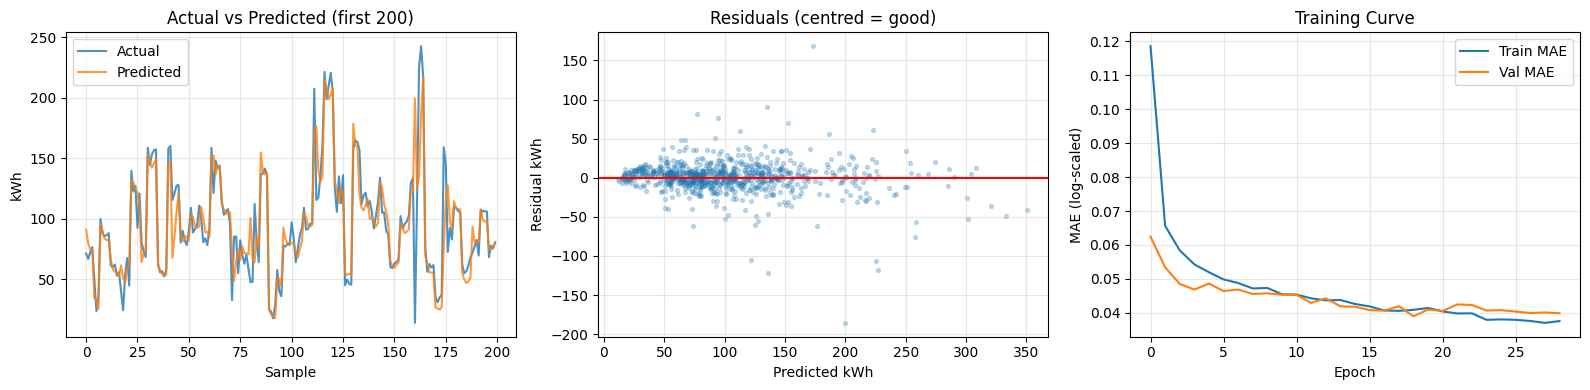

Plots saved.


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

n = min(200, len(y_true_kwh))
axes[0].plot(y_true_kwh[:n], label='Actual',    linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_kwh[:n], label='Predicted', linewidth=1.5, alpha=0.8)
axes[0].set_title('Actual vs Predicted (first 200)')
axes[0].set_xlabel('Sample'); axes[0].set_ylabel('kWh')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

residuals = y_true_kwh - y_pred_kwh
axes[1].scatter(y_pred_kwh, residuals, alpha=0.25, s=8)
axes[1].axhline(0, color='red', linewidth=1.5)
axes[1].set_title('Residuals (centred = good)')
axes[1].set_xlabel('Predicted kWh'); axes[1].set_ylabel('Residual kWh')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['mae'],     label='Train MAE')
axes[2].plot(history.history['val_mae'], label='Val MAE')
axes[2].set_title('Training Curve')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MAE (log-scaled)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/LSTM/evaluation_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plots saved.')

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

# -----------------------------------
# BASELINE PREDICTION (HYBRID MODEL)
# -----------------------------------
y_pred = y_pred_kwh.copy()
y_true = y_true_kwh.copy()

baseline_mae = mean_absolute_error(y_true, y_pred)
print('Baseline MAE:', round(baseline_mae, 4))

# -----------------------------------
# PERMUTATION IMPORTANCE
# -----------------------------------
importance_results = []

# TIME FEATURES
for i, fname in enumerate(TIME_FEATURES):
    scores = []

    for _ in range(5):
        X_perm = Xte.copy()

        for t in range(X_perm.shape[1]):
            shuffled = X_perm[:, t, i].copy()
            np.random.shuffle(shuffled)
            X_perm[:, t, i] = shuffled

        y_perm_s = model.predict([X_perm, Bte], verbose=0).flatten()
        y_perm_model = scaler_y.inverse_transform(y_perm_s.reshape(-1, 1)).flatten()
        y_perm_naive = scaler_x.inverse_transform(Xte[:, -1, 0].reshape(-1, 1)).flatten()
        y_perm = apply_product_calibration(y_perm_model, y_perm_naive)

        mae_perm = mean_absolute_error(y_true, y_perm)
        scores.append(mae_perm - baseline_mae)

    importance_results.append((fname, float(np.mean(scores))))

# BEHAVIOR FEATURES
for i, fname in enumerate(BEHAVIOR_FEATURES):
    scores = []

    for _ in range(5):
        B_perm = Bte.copy()
        shuffled = B_perm[:, i].copy()
        np.random.shuffle(shuffled)
        B_perm[:, i] = shuffled

        y_perm_s = model.predict([Xte, B_perm], verbose=0).flatten()
        y_perm_model = scaler_y.inverse_transform(y_perm_s.reshape(-1, 1)).flatten()
        y_perm_naive = scaler_x.inverse_transform(Xte[:, -1, 0].reshape(-1, 1)).flatten()
        y_perm = apply_product_calibration(y_perm_model, y_perm_naive)

        mae_perm = mean_absolute_error(y_true, y_perm)
        scores.append(mae_perm - baseline_mae)

    importance_results.append((fname, float(np.mean(scores))))

# -----------------------------------
# SORT & DISPLAY
# -----------------------------------
importance_df = pd.DataFrame(importance_results, columns=['feature', 'importance'])
importance_df = importance_df.sort_values(by='importance', ascending=False)

print('\nTop Feature Importances (MAE increase):\n')
print(importance_df.head(20))

# Optional save
importance_df.to_csv('feature_importance.csv', index=False)

Baseline MAE: 12.4749

Top Feature Importances (MAE increase):

            feature  importance
0       monthly_kwh    7.361410
7  energy_intensity    2.562789
2             lag_1    1.890231
4             lag_3    0.971775
8       ac_fraction    0.549111
5          ac_usage    0.503446
1             month    0.316592
3             lag_2    0.007936
6        wfh_impact   -0.021583


## 11. K-Means Behavioral Clustering

One profile per household (mean across all their months).
Clustering on behavioral features only — no weather, no seasonal, no prev kWh.
The K-Means labels show WHICH GROUP a new household belongs to,
and drive personalized recommendations.

In [21]:
CLUSTER_FEATURES = ['family_size', 'avg_hours_wfh']
for col in ['ac_usage', 'energy_intensity', 'has_ac', 'ac_hours_per_day']:
    if col in df1.columns:
        CLUSTER_FEATURES.append(col)

# One row per household — mean across months
hh_profile = (df1.groupby('household_id')[CLUSTER_FEATURES]
                  .mean().fillna(0).reset_index())

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(hh_profile[CLUSTER_FEATURES])

print(f'Clustering {len(hh_profile)} households')
print(f'Cluster features ({len(CLUSTER_FEATURES)}): {CLUSTER_FEATURES}')

Clustering 1287 households
Cluster features (6): ['family_size', 'avg_hours_wfh', 'ac_usage', 'energy_intensity', 'has_ac', 'ac_hours_per_day']


  K=2: silhouette=0.7888  inertia=6043
  K=3: silhouette=0.4394  inertia=4803
  K=4: silhouette=0.3399  inertia=3826
  K=5: silhouette=0.3709  inertia=3084
  K=6: silhouette=0.3771  inertia=2606
  K=7: silhouette=0.3795  inertia=2173
  K=8: silhouette=0.3878  inertia=1935


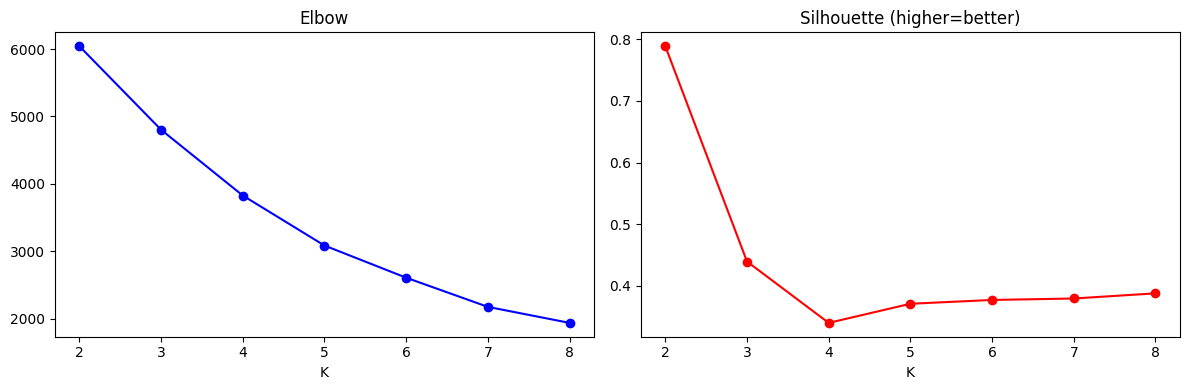

In [22]:
# Elbow + Silhouette
inertias, silhouettes = [], []
for k in range(2, 9):
    km  = KMeans(n_clusters=k, random_state=42, n_init=15)
    lbl = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, lbl,
                           sample_size=min(3000, len(X_cluster)), random_state=42)
    silhouettes.append(sil)
    print(f'  K={k}: silhouette={sil:.4f}  inertia={km.inertia_:.0f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(2,9), inertias,   'bo-'); ax[0].set_title('Elbow'); ax[0].set_xlabel('K')
ax[1].plot(range(2,9), silhouettes,'ro-'); ax[1].set_title('Silhouette (higher=better)')
ax[1].set_xlabel('K')
plt.tight_layout(); plt.show()

In [23]:
print(hh_profile.columns)

Index(['household_id', 'family_size', 'avg_hours_wfh', 'ac_usage',
       'energy_intensity', 'has_ac', 'ac_hours_per_day'],
      dtype='object')


In [27]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
hh_profile['cluster'] = kmeans.fit_predict(X_cluster)

final_sil = silhouette_score(X_cluster, hh_profile['cluster'],
                              sample_size=min(3000, len(X_cluster)), random_state=42)
print(f'Final silhouette (K={K}): {final_sil:.4f}')
print()

# Auto-label clusters by mean kWh (low → high)
df_c = df1.merge(hh_profile[['household_id','cluster']], on='household_id')
kwh_rank = df_c.groupby('cluster')['monthly_kwh'].mean().sort_values()

CLUSTER_LABELS = {
    int(kwh_rank.index[0]): 'Efficient',
    int(kwh_rank.index[1]): 'Moderate',
    int(kwh_rank.index[2]): 'High Usage',
}

print('Cluster profiles:')
for c, name in CLUSTER_LABELS.items():
    n_hh = (hh_profile['cluster'] == c).sum()
    kwh  = kwh_rank[c]
    print(f'  {name:<18}: {n_hh:4d} hh  mean={kwh:.0f} kWh ')

Final silhouette (K=3): 0.4402

Cluster profiles:
  Efficient         : 1084 hh  mean=104 kWh 
  Moderate          :  191 hh  mean=135 kWh 
  High Usage        :   12 hh  mean=167 kWh 


## 12. Bill Calculator — New Domestic Tariff (Effective 11 May 2026)

The project now estimates the monthly bill using 3 systems based on total consumption:
- Very low users: 0–60 kWh/month
- Medium users: 60–180 kWh/month
- High users: above 180 kWh/month

The estimate is calculated by applying the slab rates within the matching system, then adding the fixed charge for that system.

In [28]:
def calculate_bill(monthly_kwh: float) -> dict:
    """Estimate the monthly domestic bill using the 11 May 2026 tariff."""
    monthly_kwh = max(0.0, float(monthly_kwh))

    if monthly_kwh <= 60.0:
        system_name = 'very_low'
        fixed_charge = 0.0
        slabs = [
            (30.0, 5.00, '0-30 kWh'),
            (60.0, 9.00, '31-60 kWh'),
        ]
    elif monthly_kwh <= 180.0:
        system_name = 'medium'
        fixed_charge = 1000.0
        slabs = [
            (60.0, 14.00, '0-60 kWh'),
            (90.0, 20.00, '61-90 kWh'),
            (120.0, 28.00, '91-120 kWh'),
            (180.0, 44.00, '121-180 kWh'),
        ]
    else:
        system_name = 'high'
        fixed_charge = 2500.0
        slabs = [
            (180.0, 32.50, '0-180 kWh'),
            (float('inf'), 100.00, 'Above 180 kWh'),
        ]

    remaining = monthly_kwh
    previous_limit = 0.0
    energy_charge = 0.0
    breakdown = []

    for limit, rate, label in slabs:
        if remaining <= 0:
            break
        units = min(remaining, limit - previous_limit)
        charge = units * rate
        energy_charge += charge
        breakdown.append({
            'slab': label,
            'units': round(units, 2),
            'rate_lkr_per_unit': rate,
            'charge_lkr': round(charge, 2),
        })
        remaining -= units
        previous_limit = limit

    total_lkr = energy_charge + fixed_charge
    if fixed_charge > 0:
        breakdown.append({
            'slab': 'Fixed charge',
            'units': 1,
            'rate_lkr_per_unit': fixed_charge,
            'charge_lkr': round(fixed_charge, 2),
        })

    return {
        'tariff_system': system_name,
        'energy_charge_lkr': round(energy_charge, 2),
        'fixed_charge_lkr': round(fixed_charge, 2),
        'total_lkr': round(total_lkr, 2),
        'slab_breakdown': breakdown,
    }


# Verify the revised tariff against the example and a few edge cases.
for kwh in [25, 55, 150, 220]:
    b = calculate_bill(kwh)
    print(f'{kwh:3d} kWh -> {b["tariff_system"]} | total LKR {b["total_lkr"]:,.2f}')
    print(pd.DataFrame(b['slab_breakdown']).to_string(index=False))
    print()

print('Example from the prompt: 150 kWh = 60×14 + 30×20 + 60×28 + 1000 fixed charge = LKR 4,600')

 25 kWh -> very_low | total LKR 125.00
    slab  units  rate_lkr_per_unit  charge_lkr
0-30 kWh   25.0                5.0       125.0

 55 kWh -> very_low | total LKR 375.00
     slab  units  rate_lkr_per_unit  charge_lkr
 0-30 kWh   30.0                5.0       150.0
31-60 kWh   25.0                9.0       225.0

150 kWh -> medium | total LKR 4,600.00
        slab  units  rate_lkr_per_unit  charge_lkr
    0-60 kWh   60.0               14.0       840.0
   61-90 kWh   30.0               20.0       600.0
  91-120 kWh   30.0               28.0       840.0
 121-180 kWh   30.0               44.0      1320.0
Fixed charge    1.0             1000.0      1000.0

220 kWh -> high | total LKR 12,350.00
         slab  units  rate_lkr_per_unit  charge_lkr
    0-180 kWh  180.0               32.5      5850.0
Above 180 kWh   40.0              100.0      4000.0
 Fixed charge    1.0             2500.0      2500.0

Example from the prompt: 150 kWh = 60×14 + 30×20 + 60×28 + 1000 fixed charge = LKR 4,600


## 13. Full Prediction Pipeline

In [29]:
def predict_next_month_consumption(last_sequence: np.ndarray, behavior_vector: np.ndarray) -> float:
    """Predict next-month kWh from time sequence + behavior vector."""
    seq = np.asarray(last_sequence, dtype=np.float32)
    beh = np.asarray(behavior_vector, dtype=np.float32)

    if seq.shape != (SEQ_LEN, len(TIME_FEATURES)):
        raise ValueError(
            f'Expected sequence shape {(SEQ_LEN, len(TIME_FEATURES))}, got {seq.shape}'
        )
    if beh.shape != (len(BEHAVIOR_FEATURES),):
        raise ValueError(
            f'Expected behavior shape {(len(BEHAVIOR_FEATURES),)}, got {beh.shape}'
        )

    seq_scaled = seq.copy()
    for idx in TIME_SCALE_FEATURE_IDXS:
        seq_scaled[:, idx] = scaler_x.transform(seq[:, idx].reshape(-1, 1)).ravel()
    seq_scaled = apply_time_feature_weights(seq_scaled[np.newaxis, ...])[0]

    beh_scaled = scaler_b.transform(beh.reshape(1, -1)).astype(np.float32)

    pred_scaled = model.predict([seq_scaled[np.newaxis, ...], beh_scaled], verbose=0)
    model_kwh = float(scaler_y.inverse_transform(pred_scaled)[0, 0])
    naive_kwh = float(seq[-1, 0])
    pred_kwh = apply_product_calibration(np.array([model_kwh]), np.array([naive_kwh]))[0]
    return float(pred_kwh)

# Example: predict the next month for the last household in the dataset
example_hh = df1['household_id'].iloc[-1]
g = df1[df1['household_id'] == example_hh].sort_values('month')

last_sequence = g[TIME_FEATURES].tail(SEQ_LEN).to_numpy(dtype=np.float32)
last_behavior = g[BEHAVIOR_FEATURES].iloc[-1].to_numpy(dtype=np.float32)

if len(last_sequence) == SEQ_LEN:
    next_month_pred = predict_next_month_consumption(last_sequence, last_behavior)
    print(f'Example household: {example_hh}')
    print(f'Predicted next month kWh: {next_month_pred:.2f}')
else:
    print('Not enough history for example prediction.')

Example household: ID3822
Predicted next month kWh: 165.29


## 14. Test Prediction on a Real Household

In [33]:
# =========================================
# TEST PREDICTION ON REAL TEST SEQUENCES
# =========================================

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

sample_count = min(5, len(Xte))
sample_indices = rng.choice(len(Xte), size=sample_count, replace=False)

hh_test = hh_seq[te]
y_true_test = yte

results = []

for idx in sample_indices:
    hh = hh_test[idx]

    seq_raw = Xte_time_raw[idx].copy()
    beh_raw = scaler_b.inverse_transform(Bte[idx:idx+1])[0]
    pred_kwh = predict_next_month_consumption(seq_raw, beh_raw)
    true_kwh = float(y_true_test[idx])

    results.append({
        'household': hh,
        'true_kwh': round(true_kwh, 2),
        'pred_kwh': round(pred_kwh, 2),
        'error': round(abs(pred_kwh - true_kwh), 2),
    })

results_df = pd.DataFrame(results).sort_values('error')
results_df

,household,true_kwh,pred_kwh,error
2,ID2811,126.87,131.13,4.25
0,ID3150,56.80,48.97,7.83
4,ID2133,121.72,112.57,9.15
1,ID2188,34.37,46.97,12.60
3,ID0645,85.23,46.93,38.29


## 15. Save All Artifacts

In [32]:
# Save LSTM artifacts for the hybrid model
joblib.dump(scaler_x, '../models/LSTM/scaler_x.pkl')
joblib.dump(scaler_b, '../models/LSTM/scaler_b.pkl')
joblib.dump(scaler_y, '../models/LSTM/scaler_y.pkl')

# Save calibration parameters used by production inference
calibration_meta = {
    'blend_alpha': float(BLEND_ALPHA),
    'blend_scale': float(BLEND_SCALE),
    'blend_bias_kwh': float(BLEND_BIAS_KWH),
    'tier_edges': [float(x) for x in VAL_TIER_EDGES.tolist()],
    'tier_biases': [float(x) for x in VAL_TIER_BIASES.tolist()],
}
with open('../models/LSTM/calibration_meta.json', 'w') as f:
    json.dump(calibration_meta, f, indent=2)

# Save K-Means artifacts
joblib.dump(kmeans, '../models/K-means/kmeans_model.pkl')
joblib.dump(scaler_cluster, '../models/K-means/scaler_cluster.pkl')

# Save cluster metadata
cluster_meta = {
    'cluster_labels': {int(k): v for k, v in CLUSTER_LABELS.items()},
    'cluster_features': CLUSTER_FEATURES,
    'n_clusters': K,
    'silhouette_score': round(float(final_sil), 4),
}
with open('../models/K-means/cluster_meta.json', 'w') as f:
    json.dump(cluster_meta, f, indent=2)

meta = {
    'time_features': TIME_FEATURES,
    'behavior_features': BEHAVIOR_FEATURES,
    'seq_len': SEQ_LEN,
    'n_time_features': len(TIME_FEATURES),
    'n_behavior_features': len(BEHAVIOR_FEATURES),
    'calibration': calibration_meta,
    'metrics': {
        'mae_kwh': round(float(mae), 2),
        'rmse_kwh': round(float(rmse), 2),
        'wmape_pct': round(float(wmape), 2),
        'r2': round(float(r2), 4),
    }
}
with open('../models/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('All artifacts saved:')
print('LSTM models:')
for p in sorted(Path('../models/LSTM').rglob('*')):
    if p.is_file():
        size = p.stat().st_size / 1024
        print(f'  {p}  ({size:.1f} KB)')
print()
print('K-Means models:')
for p in sorted(Path('../models/K-means').rglob('*')):
    if p.is_file():
        size = p.stat().st_size / 1024
        print(f'  {p}  ({size:.1f} KB)')

All artifacts saved:
LSTM models:
  ../models/LSTM/calibration_meta.json  (0.3 KB)
  ../models/LSTM/evaluation_plots.png  (148.0 KB)
  ../models/LSTM/lstm_model.keras  (172.4 KB)
  ../models/LSTM/scaler_b.pkl  (0.7 KB)
  ../models/LSTM/scaler_x.pkl  (0.7 KB)
  ../models/LSTM/scaler_y.pkl  (0.7 KB)

K-Means models:
  ../models/K-means/cluster_meta.json  (0.3 KB)
  ../models/K-means/kmeans_model.pkl  (5.9 KB)
  ../models/K-means/scaler_cluster.pkl  (1.1 KB)


## 16. Final Summary

In [34]:
print('=' * 55)
print('         HYBRID LSTM + K-MEANS — FINAL RESULTS')
print('=' * 55)
print(f'  MAE   (kWh):    {mae:.2f}   {"✓ PASS" if mae  < 20 else "✗ FAIL"}  target < 20')
print(f'  RMSE  (kWh):    {rmse:.2f}   {"✓ PASS" if rmse < 30 else "✗ FAIL"}  target < 30')
print(f'  WMAPE (%):      {wmape:.1f}%   {"✓ PASS" if wmape < 15 else "✗ FAIL"}  target < 15%')
print(f'  R² Score:       {r2:.4f}   {"✓ PASS" if r2 > 0.85 else "✗ FAIL"}  target > 0.85')
print(f'  Silhouette:     {final_sil:.4f}')
print()
print('  predict.py pipeline:')
print('    input → scaler_x (MinMax time) + scaler_b (Standard behavior)')
print('    → LSTM(time) + Dense(behavior) → concat → scaler_y.inverse')
print('    → blend with naive(last month kWh) + bias calibration → kWh')
print('    → calculate_bill() → cluster assignment')
print('')

         HYBRID LSTM + K-MEANS — FINAL RESULTS
  MAE   (kWh):    12.47   ✓ PASS  target < 20
  RMSE  (kWh):    20.40   ✓ PASS  target < 30
  WMAPE (%):      12.1%   ✓ PASS  target < 15%
  R² Score:       0.8713   ✓ PASS  target > 0.85
  Silhouette:     0.4402

  predict.py pipeline:
    input → scaler_x (MinMax time) + scaler_b (Standard behavior)
    → LSTM(time) + Dense(behavior) → concat → scaler_y.inverse
    → blend with naive(last month kWh) + bias calibration → kWh
    → calculate_bill() → cluster assignment

